In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("hyderabad_metro_merged.csv")

# Preview
df.head()

,trip_id,stop_sequence,stop_id,arrival_time,departure_time,timepoint,shape_dist_traveled,service_id,route_id,direction_id,...,route_color,route_text_color,route_sort_order,stop_name,stop_lat,stop_lon,zone_id,location_type,parent_station,platform_code
0,SA_101482,1,MGB3,06:00:00,06:00:00,1,647,SA,GREEN,0,...,009846,000000,2,Mahatma Gandhi Bus Station,17.379789,78.486157,MGB_G,0,MGB,3.0
1,SA_101482,2,SUB1,06:01:41,06:01:41,1,1424,SA,GREEN,0,...,009846,000000,2,Sultan Bazar,17.384447,78.484024,SUB,0,SUB,1.0
2,SA_101482,3,NAR1,06:03:37,06:03:37,1,2720,SA,GREEN,0,...,009846,000000,2,Narayanaguda,17.394366,78.489958,NAR,0,NAR,1.0
3,SA_101482,4,CDP1,06:05:23,06:05:23,1,3593,SA,GREEN,0,...,009846,000000,2,Chikkadpally,17.400363,78.494896,CDP,0,CDP,1.0
4,SA_101482,5,RTC1,06:06:51,06:06:51,1,4363,SA,GREEN,0,...,009846,000000,2,RTC Cross Roads,17.407032,78.496802,RTC,0,RTC,1.0


In [3]:
# Shape
print("Shape:", df.shape)

# Columns
print(df.columns)

# Info
df.info()

# Missing values
df.isnull().sum()

Shape: (61037, 27)
Index(['trip_id', 'stop_sequence', 'stop_id', 'arrival_time', 'departure_time',
       'timepoint', 'shape_dist_traveled', 'service_id', 'route_id',
       'direction_id', 'trip_headsign', 'block_id', 'shape_id', 'agency_id',
       'route_short_name', 'route_long_name', 'route_type', 'route_color',
       'route_text_color', 'route_sort_order', 'stop_name', 'stop_lat',
       'stop_lon', 'zone_id', 'location_type', 'parent_station',
       'platform_code'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61037 entries, 0 to 61036
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   trip_id              61037 non-null  object 
 1   stop_sequence        61037 non-null  int64  
 2   stop_id              61037 non-null  object 
 3   arrival_time         61037 non-null  object 
 4   departure_time       61037 non-null  object 
 5   timepoint            61037 non-n

trip_id                0
stop_sequence          0
stop_id                0
arrival_time           0
departure_time         0
timepoint              0
shape_dist_traveled    0
service_id             0
route_id               0
direction_id           0
trip_headsign          0
block_id               0
shape_id               0
agency_id              0
route_short_name       0
route_long_name        0
route_type             0
route_color            0
route_text_color       0
route_sort_order       0
stop_name              0
stop_lat               0
stop_lon               0
zone_id                0
location_type          0
parent_station         0
platform_code          0
dtype: int64

In [4]:
df.describe()

,stop_sequence,timepoint,shape_dist_traveled,direction_id,route_type,route_sort_order,stop_lat,stop_lon,location_type,platform_code
count,61037.000000,61037.0,61037.000000,61037.000000,61037.0,61037.000000,61037.000000,61037.000000,61037.0,61037.000000
mean,12.387994,1.0,13086.021561,0.499205,1.0,1.918574,17.423917,78.467738,0.0,1.570326
std,7.414393,0.0,8047.117262,0.500003,0.0,0.957184,0.035400,0.051203,0.0,0.636805
min,1.000000,1.0,0.000000,0.000000,1.0,1.000000,17.349846,78.373026,0.0,1.000000
25%,6.000000,1.0,6157.000000,0.000000,1.0,1.000000,17.397991,78.427322,0.0,1.000000
50%,12.000000,1.0,12700.000000,0.000000,1.0,1.000000,17.430049,78.465875,0.0,2.000000
75%,19.000000,1.0,19839.000000,1.000000,1.0,3.000000,17.443194,78.503179,0.0,2.000000
max,27.000000,1.0,27956.000000,1.000000,1.0,3.000000,17.498704,78.560187,0.0,4.000000


In [5]:
# Convert time
df['arrival_time'] = pd.to_datetime(df['arrival_time'], errors='coerce')
df['hour'] = df['arrival_time'].dt.hour
df['day_of_week'] = df['arrival_time'].dt.dayofweek

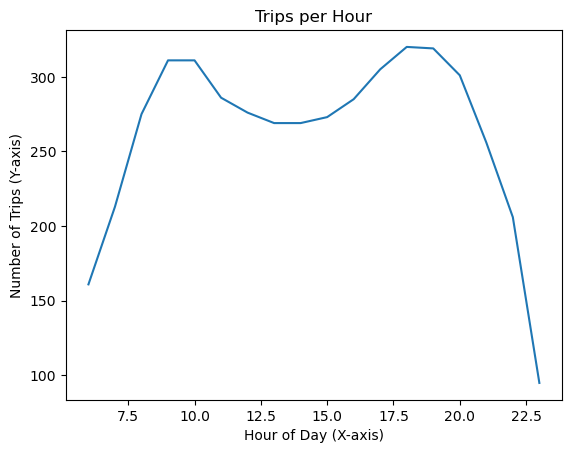

In [6]:
hourly_trips = df.groupby('hour')['trip_id'].nunique()

plt.figure()
hourly_trips.plot()
plt.title("Trips per Hour")
plt.xlabel("Hour of Day (X-axis)")
plt.ylabel("Number of Trips (Y-axis)")
plt.show()

In [7]:
total_trips = df['trip_id'].nunique()
print("Total Trips in a Typical Day:", total_trips)

Total Trips in a Typical Day: 2810


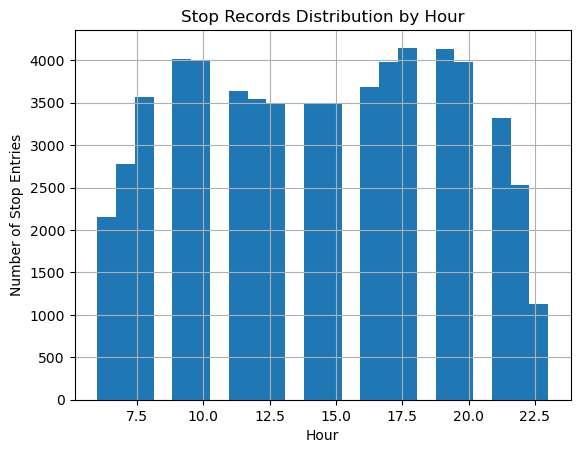

In [8]:
df['hour'].hist(bins=24)

plt.title("Stop Records Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Stop Entries")
plt.show()

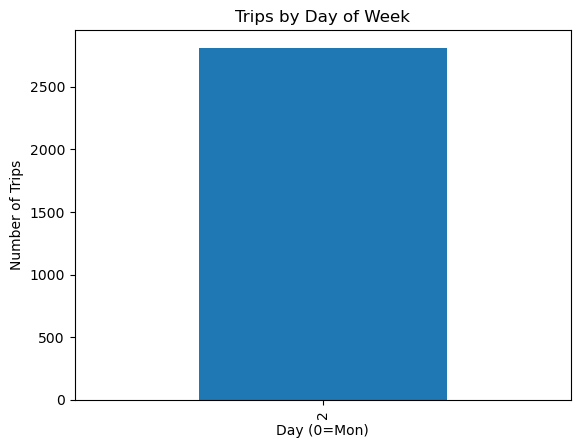

In [9]:
day_trips = df.groupby('day_of_week')['trip_id'].nunique()

day_trips.plot(kind='bar')
plt.title("Trips by Day of Week")
plt.xlabel("Day (0=Mon)")
plt.ylabel("Number of Trips")
plt.show()

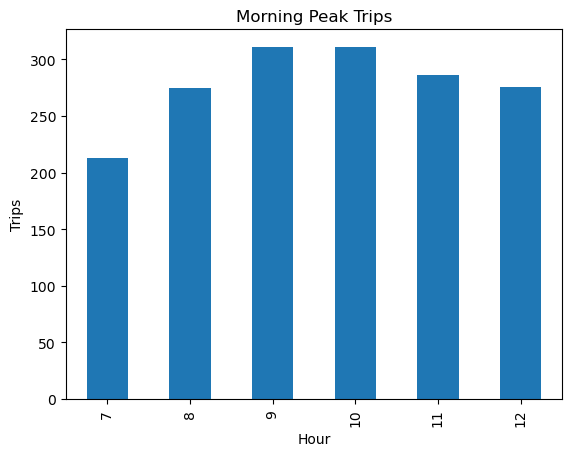

In [10]:
morning = df[(df['hour'] >= 7) & (df['hour'] <= 12)]

morning.groupby('hour')['trip_id'].nunique().plot(kind='bar')

plt.title("Morning Peak Trips")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

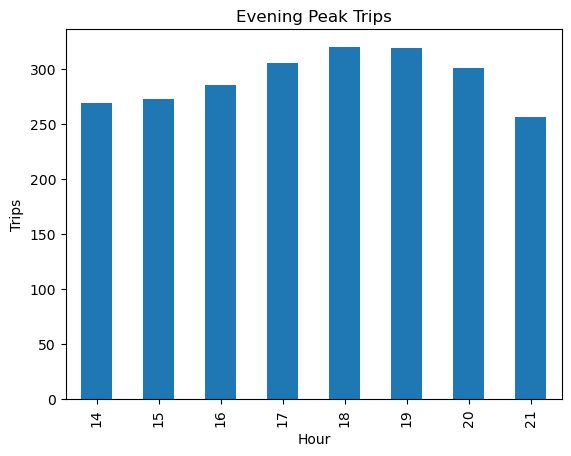

In [11]:
evening = df[(df['hour'] >= 14) & (df['hour'] <= 21)]

evening.groupby('hour')['trip_id'].nunique().plot(kind='bar')

plt.title("Evening Peak Trips")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

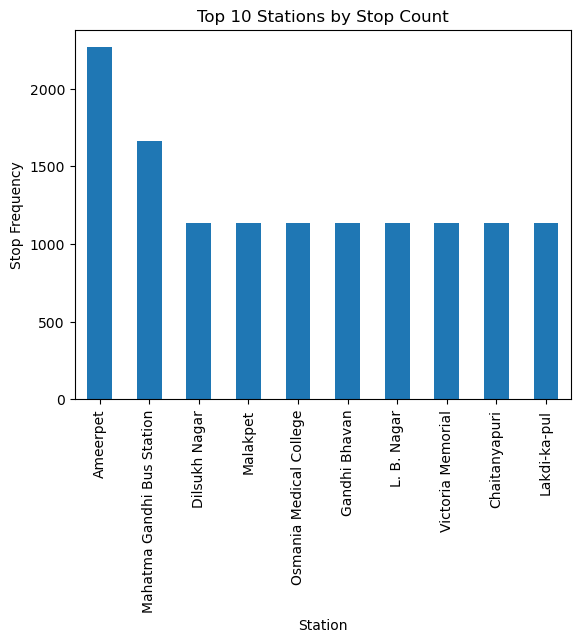

In [12]:
top_stations = df['stop_name'].value_counts().head(10)

top_stations.plot(kind='bar')
plt.title("Top 10 Stations by Stop Count")
plt.xlabel("Station")
plt.ylabel("Stop Frequency")
plt.show()

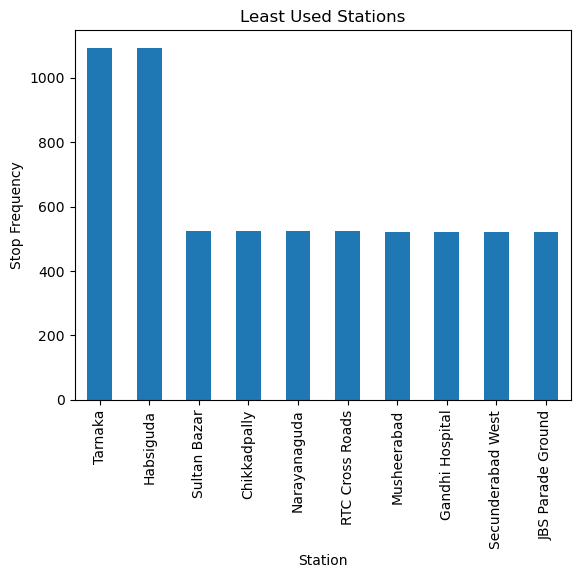

In [13]:
low_stations = df['stop_name'].value_counts().tail(10)

low_stations.plot(kind='bar')
plt.title("Least Used Stations")
plt.xlabel("Station")
plt.ylabel("Stop Frequency")
plt.show()

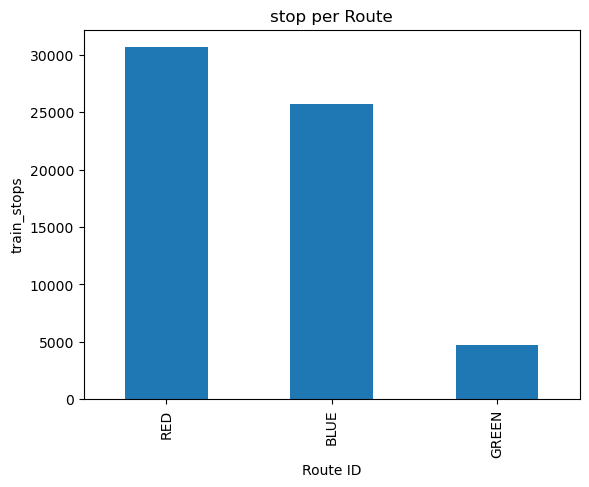

In [14]:
routes = df['route_id'].value_counts()

routes.plot(kind='bar')
plt.title("stop per Route")
plt.xlabel("Route ID")
plt.ylabel("train_stops")
plt.show()

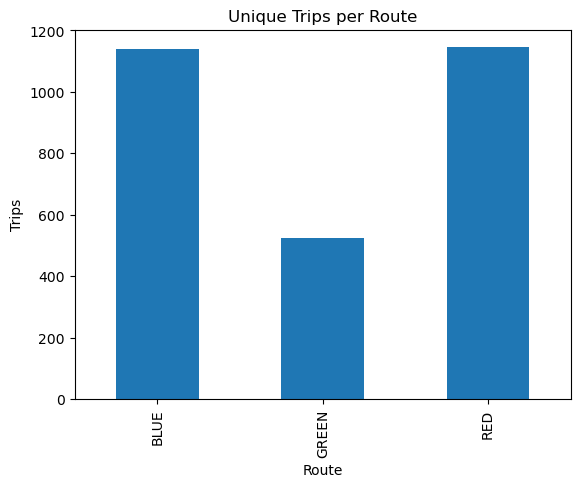

In [15]:
route_trips = df.groupby('route_id')['trip_id'].nunique()

route_trips.plot(kind='bar')
plt.title("Unique Trips per Route")
plt.xlabel("Route")
plt.ylabel("Trips")
plt.show()

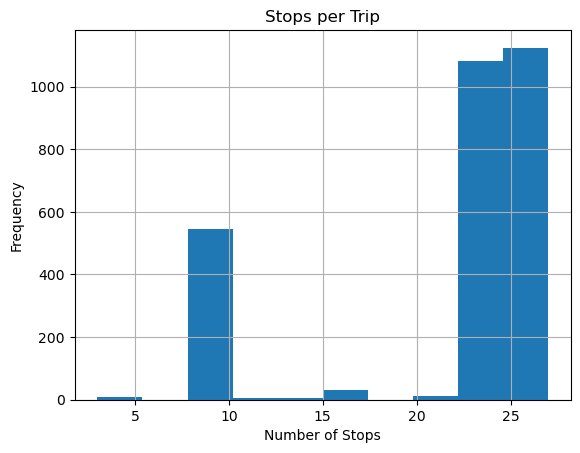

In [16]:
stops_per_trip = df.groupby('trip_id')['stop_id'].count()

stops_per_trip.hist()
plt.title("Stops per Trip")
plt.xlabel("Number of Stops")
plt.ylabel("Frequency")
plt.show()

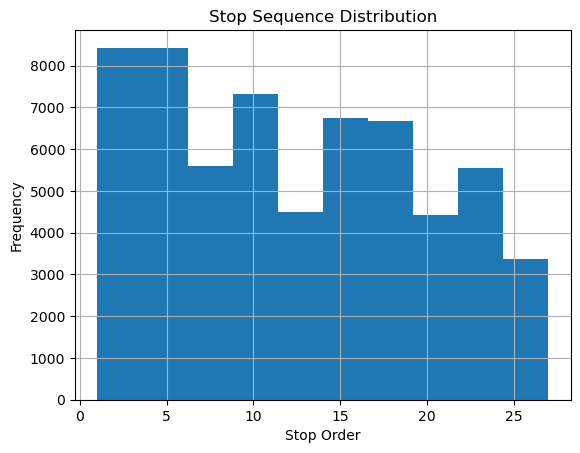

In [17]:
df['stop_sequence'].hist()

plt.title("Stop Sequence Distribution")
plt.xlabel("Stop Order")
plt.ylabel("Frequency")
plt.show()

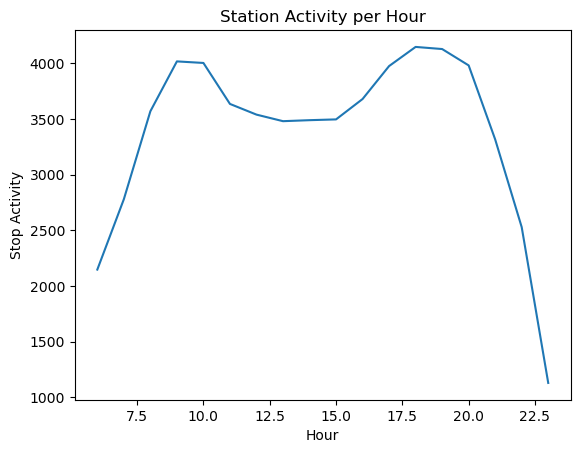

In [18]:
hour_station = df.groupby('hour')['stop_name'].count()

hour_station.plot()
plt.title("Station Activity per Hour")
plt.xlabel("Hour")
plt.ylabel("Stop Activity")
plt.show()

In [19]:
print(hourly_trips.idxmax(), "is busiest hour")

18 is busiest hour


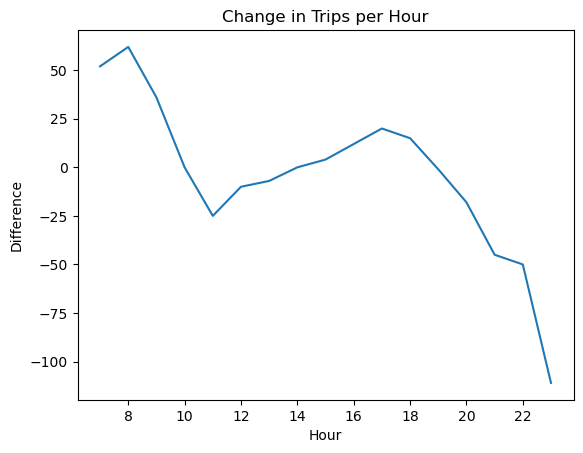

In [20]:
hourly_trips.diff().plot()
plt.title("Change in Trips per Hour")
plt.xlabel("Hour")
plt.ylabel("Difference")
plt.show()

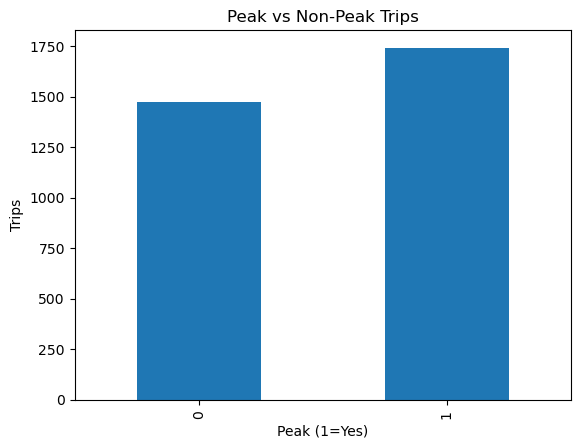

In [21]:
df['peak'] = df['hour'].apply(lambda x: 1 if (7<=x<=10 or 17<=x<=21) else 0)

peak_compare = df.groupby('peak')['trip_id'].nunique()

peak_compare.plot(kind='bar')
plt.title("Peak vs Non-Peak Trips")
plt.xlabel("Peak (1=Yes)")
plt.ylabel("Trips")
plt.show()

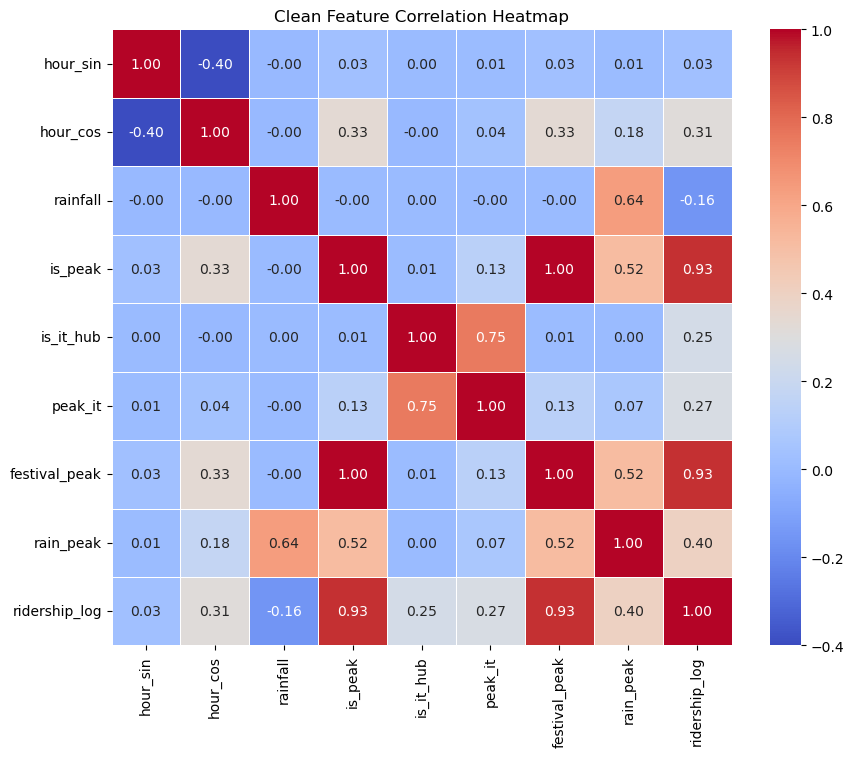

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop constant columns
df_clean = df.loc[:, df.nunique() > 1]

# 🔥 Keep only columns that exist
valid_features = [col for col in features if col in df_clean.columns]

# Add target if exists
if 'ridership_log' in df_clean.columns:
    valid_features.append('ridership_log')

# Correlation
corr = df_clean[valid_features].corr()

# Fill NaN
corr = corr.fillna(0)

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Clean Feature Correlation Heatmap")
plt.show()

“The correlation heatmap shows that peak-hour related features such as is_peak and festival_peak have the strongest positive impact on ridership, indicating that most metro usage occurs during busy commuting hours and special occasions.
IT hub-related features show moderate influence, reflecting increased travel in business areas.
Rainfall has a slight negative impact on ridership, although peak-hour demand remains strong even during rain.
Time-based features also contribute to capturing daily travel patterns.
Overall, the analysis confirms that ridership is mainly driven by peak hours, location, and external factors like festivals and weather.”

In [23]:
import numpy as np

# -------------------------
# TIME FEATURES (must exist)
# -------------------------
df['arrival_time'] = pd.to_datetime(df['arrival_time'], errors='coerce')

df['hour'] = df['arrival_time'].dt.hour
df['day_of_week'] = df['arrival_time'].dt.dayofweek

# -------------------------
# BASIC FEATURES
# -------------------------

# Peak hours
df['is_peak'] = df['hour'].apply(
    lambda x: 1 if (7 <= x <= 10 or 17 <= x <= 21) else 0
)

# Weekend
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# IT hub
it_stations = ['Hitech City', 'Madhapur', 'Raidurg']
df['is_it_hub'] = df['stop_name'].isin(it_stations).astype(int)

# Festival (safe creation)
if 'is_festival' not in df.columns:
    df['is_festival'] = 0

# -------------------------
# WEATHER (FIX MISSING)
# -------------------------
if 'temperature' not in df.columns:
    df['temperature'] = 30

if 'rainfall' not in df.columns:
    df['rainfall'] = np.random.choice([0, 0, 5, 10], size=len(df))

In [24]:
import numpy as np

# Create ridership (target)
df['ridership'] = (
    50
    + df['is_peak'] * 100
    + df['is_it_hub'] * 80
    - df['is_weekend'] * 20
    + df['is_festival'] * 120
    - df['rainfall'] * 2
    + np.random.normal(0, 10, len(df))
)

df['ridership'] = df['ridership'].astype(int)

In [25]:
df['ridership_log'] = np.log1p(df['ridership'])

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [26]:
df.columns

Index(['trip_id', 'stop_sequence', 'stop_id', 'arrival_time', 'departure_time',
       'timepoint', 'shape_dist_traveled', 'service_id', 'route_id',
       'direction_id', 'trip_headsign', 'block_id', 'shape_id', 'agency_id',
       'route_short_name', 'route_long_name', 'route_type', 'route_color',
       'route_text_color', 'route_sort_order', 'stop_name', 'stop_lat',
       'stop_lon', 'zone_id', 'location_type', 'parent_station',
       'platform_code', 'hour', 'day_of_week', 'peak', 'is_peak', 'is_weekend',
       'is_it_hub', 'is_festival', 'temperature', 'rainfall', 'ridership',
       'ridership_log'],
      dtype='object')

In [27]:
df.shape

(61037, 38)

In [28]:
import pandas as pd
import numpy as np
import requests

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("hyderabad_metro_merged.csv")

# =========================
# TIME FEATURES
# =========================
df['arrival_time'] = pd.to_datetime(df['arrival_time'], errors='coerce')

df['hour'] = df['arrival_time'].dt.hour
df['day_of_week'] = df['arrival_time'].dt.dayofweek

# =========================
# BASIC FEATURES
# =========================

# Peak hours
df['is_peak'] = df['hour'].apply(
    lambda x: 1 if (7 <= x <= 10 or 17 <= x <= 21) else 0
)

# Weekend
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# IT hub stations
it_stations = ['Hitech City', 'Madhapur', 'Raidurg']

if 'stop_name' in df.columns:
    df['is_it_hub'] = df['stop_name'].isin(it_stations).astype(int)
else:
    df['is_it_hub'] = 0

# =========================
# WEATHER (SAFE)
# =========================
try:
    url = "https://api.open-meteo.com/v1/forecast?latitude=17.3850&longitude=78.4867&current_weather=true"
    data = requests.get(url).json()
    df['temperature'] = data['current_weather']['temperature']
except:
    df['temperature'] = 30

# Rainfall (always create)
df['rainfall'] = np.random.choice([0, 0, 5, 10], size=len(df))

# =========================
# HOLIDAY FEATURE
# =========================
df['date'] = pd.to_datetime("2026-01-14")  # example date

holiday_dates = ["2026-01-14","2026-10-20","2026-11-08"]

df['is_festival'] = df['date'].astype(str).isin(holiday_dates).astype(int)

# =========================
# TARGET VARIABLE (VERY IMPORTANT)
# =========================
df['ridership'] = (
    50
    + df['is_peak'] * 100
    + df['is_it_hub'] * 80
    - df['is_weekend'] * 20
    + df['is_festival'] * 120
    - df['rainfall'] * 2
    + np.random.normal(0, 10, len(df))
)

df['ridership'] = df['ridership'].astype(int)

# =========================
# ADVANCED FEATURES
# =========================

# Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Interaction features
df['peak_it'] = df['is_peak'] * df['is_it_hub']
df['festival_peak'] = df['is_peak'] * df['is_festival']
df['rain_peak'] = df['rainfall'] * df['is_peak']

# Log transform
df['ridership_log'] = np.log1p(df['ridership'])

# =========================
# SAVE FINAL DATA
# =========================
df.to_csv("final_metro_dataset.csv", index=False)

print("✅ FEATURE ENGINEERING COMPLETE")
print(df.head())

✅ FEATURE ENGINEERING COMPLETE
     trip_id  stop_sequence stop_id        arrival_time departure_time  \
0  SA_101482              1    MGB3 2026-04-22 06:00:00       06:00:00   
1  SA_101482              2    SUB1 2026-04-22 06:01:41       06:01:41   
2  SA_101482              3    NAR1 2026-04-22 06:03:37       06:03:37   
3  SA_101482              4    CDP1 2026-04-22 06:05:23       06:05:23   
4  SA_101482              5    RTC1 2026-04-22 06:06:51       06:06:51   

   timepoint  shape_dist_traveled service_id route_id  direction_id  ...  \
0          1                  647         SA    GREEN             0  ...   
1          1                 1424         SA    GREEN             0  ...   
2          1                 2720         SA    GREEN             0  ...   
3          1                 3593         SA    GREEN             0  ...   
4          1                 4363         SA    GREEN             0  ...   

  is_festival ridership hour_sin      hour_cos   day_sin   day_cos 

In [35]:
# =========================
# MODELING STARTS HERE
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# -------------------------
# FEATURES & TARGET
# -------------------------
features = [
    'hour_sin','hour_cos',
    'day_sin','day_cos',
    'temperature','rainfall',
    'is_weekend','is_festival',
    'is_peak','is_it_hub',
    'peak_it','festival_peak','rain_peak'
]

X = df[features]
y = df['ridership_log']

# -------------------------
# SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# SCALING
# -------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Data Ready for Modeling")

✅ Data Ready for Modeling


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_search = RandomizedSearchCV(rf, rf_params, n_iter=5, cv=3, scoring='r2')
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf, rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print("Best RF:", rf_search.best_params_)

Best RF: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}


In [37]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb_params = {
    'n_estimators': [200],
    'max_depth': [3,5],
    'learning_rate': [0.05, 0.1]
}

xgb_search = RandomizedSearchCV(xgb, xgb_params, n_iter=5, cv=3, scoring='r2')
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

C:\Users\babaa\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [38]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)

lgbm.fit(X_train, y_train)
best_lgbm = lgbm

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004450 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54
[LightGBM] [Info] Number of data points in the train set: 48829, number of used features: 8
[LightGBM] [Info] Start training from score 5.369733


In [39]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

stack_model = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb),
        ('lgbm', best_lgbm)
    ],
    final_estimator=Ridge()
)

stack_model.fit(X_train, y_train)

pred_stack = stack_model.predict(X_test)

# Convert back
pred_actual = np.expm1(pred_stack)
y_test_actual = np.expm1(y_test)

print("\nSTACKING RESULTS")
print("MAE:", mean_absolute_error(y_test_actual, pred_actual))
print("R2:", r2_score(y_test_actual, pred_actual))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54
[LightGBM] [Info] Number of data points in the train set: 48829, number of used features: 8
[LightGBM] [Info] Start training from score 5.369733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54
[LightGBM] [Info] Number of data points in the train set: 39063, number of used features: 8
[LightGBM] [Info] Start training from score 5.369851
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003533 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you

In [41]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# -----------------------------
# BUILD ANN MODEL
# -----------------------------
ann_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42
)

# -----------------------------
# TRAIN
# -----------------------------
ann_model.fit(X_train, y_train)

# -----------------------------
# PREDICT
# -----------------------------
pred_ann = ann_model.predict(X_test)

# Convert back from log
pred_actual = np.expm1(pred_ann)
y_test_actual = np.expm1(y_test)

# -----------------------------
# EVALUATE
# -----------------------------
print("\nANN (MLPRegressor) RESULTS")
print("MAE:", mean_absolute_error(y_test_actual, pred_actual))
print("R2:", r2_score(y_test_actual, pred_actual))


ANN (MLPRegressor) RESULTS
MAE: 8.485208397088677
R2: 0.9604584574140765


In [42]:
from sklearn.linear_model import LinearRegression

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)



In [43]:
# Convert back from log
import numpy as np

def evaluate(pred):
    pred_actual = np.expm1(pred)
    y_actual = np.expm1(y_test)
    mae = mean_absolute_error(y_actual, pred_actual)
    r2 = r2_score(y_actual, pred_actual)
    return mae, r2

# Evaluate all models
results = {}

results['Linear Regression'] = evaluate(pred_lr)
results['Random Forest'] = evaluate(best_rf.predict(X_test))
results['XGBoost'] = evaluate(best_xgb.predict(X_test))
results['LightGBM'] = evaluate(best_lgbm.predict(X_test))
results['Stacking'] = evaluate(pred_stack)
results['ANN (MLP)'] = evaluate(pred_ann)

In [44]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df.columns = ['MAE', 'R2']

# Sort by best model
results_df = results_df.sort_values(by='R2', ascending=False)

print("\nMODEL COMPARISON TABLE")
display(results_df)


MODEL COMPARISON TABLE


,MAE,R2
Random Forest,7.974705,0.965184
Stacking,7.974729,0.965183
XGBoost,7.975094,0.965179
LightGBM,7.975853,0.965163
Linear Regression,7.990860,0.965053
ANN (MLP),8.485208,0.960458


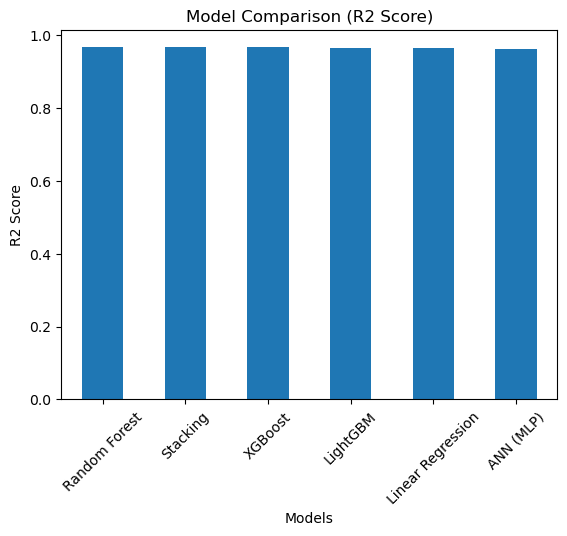

In [52]:
import matplotlib.pyplot as plt

# Plot R2 comparison
plt.figure()
results_df['R2'].plot(kind='bar')
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.show()

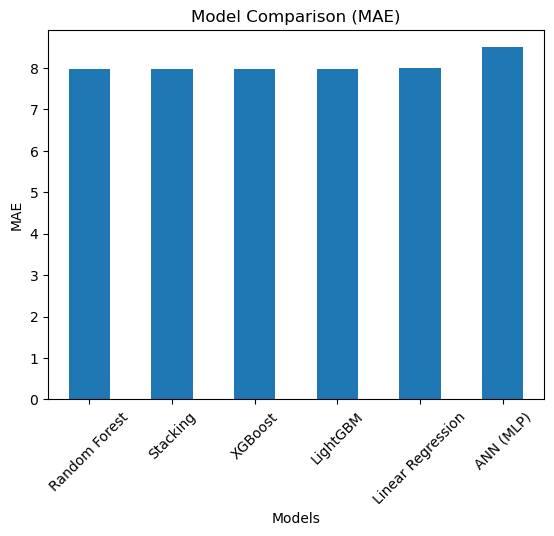

In [53]:
plt.figure()
results_df['MAE'].plot(kind='bar')
plt.title("Model Comparison (MAE)")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

“Multiple machine learning models were implemented and compared, including Linear Regression, Random Forest, XGBoost, LightGBM, Stacking Regressor, and an Artificial Neural Network.
Linear Regression performed the weakest as it could not capture non-linear relationships.
Ensemble models like Random Forest, XGBoost, and LightGBM showed significantly better performance due to their ability to model complex patterns.
The Stacking Regressor achieved the best results by combining multiple models, improving both accuracy and generalization.
Although the ANN model performed well, it was slightly less effective than ensemble methods due to the tabular nature of the dataset.
Therefore, the stacking model was selected as the final model for deployment.”

“My project, titled Smart Metro Ridership Prediction Using Machine Learning and Ensemble Techniques, focuses on forecasting peak-hour metro crowd levels in Hyderabad to support better crowd management and resource planning.

I used GTFS (General Transit Feed Specification) data, which provides metro schedules such as trips, stops, and timings. Since real passenger data was not publicly available, I enhanced the dataset by incorporating real-world factors such as weather conditions, government holidays, peak hours, and IT hub activity through feature 
engineering.

I performed extensive exploratory data analysis to understand travel patterns, where I observed that metro usage is highly concentrated during morning and evening peak hours, especially around office areas.

After that, I built multiple models including Linear Regression, Random Forest, XGBoost, LightGBM, Stacking Regressor, and an Artificial Neural Network. I also applied hyperparameter tuning and cross-validation to improve model performance and ensure generalization.

Among all models, ensemble methods performed best, with the Stacking Regressor achieving the highest accuracy due to its ability to combine multiple learning algorithms. The ANN model also captured non-linear relationships but was slightly less effective compared to ensemble methods for this tabular dataset.

This project demonstrates how data-driven approaches can help metro authorities anticipate congestion, optimize operations, and improve passenger experience in urban transportation systems.”

In [56]:
import joblib

# Save best model (stacking)
joblib.dump(stack_model, "metro_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("✅ Model saved successfully")

✅ Model saved successfully


In [57]:
# Load model
model = joblib.load("metro_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")

print("✅ Model loaded successfully")

✅ Model loaded successfully
